In [1]:
# ============================================
# MONTE CARLO PORTFOLIO RISK SIMULATOR
# Step 1: Install & Import Libraries
# ============================================

!pip -q install yfinance streamlit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

print("Libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 45.7 MB/s eta 0:00:00
Libraries imported successfully!


In [2]:
# ============================================
# Step 2: Download Historical Data
# ============================================

import yfinance as yf

tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]

data = yf.download(
    tickers,
    start="2020-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)

prices = data["Close"]

prices.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2020-01-02,72.271538,94.900497,67.832520,151.544281,5.963804
2020-01-03,71.568924,93.748497,67.477646,149.657242,5.868347
2020-01-06,72.139191,95.143997,69.276207,150.044067,5.892956
2020-01-07,71.799934,95.343002,69.142410,148.676071,5.964301
2020-01-08,72.954910,94.598503,69.634537,151.044205,5.975487


In [3]:
print("Dataset shape:", prices.shape)

print("\nColumns:")
print(prices.columns.tolist())

print("\nMissing values:")
print(prices.isnull().sum())

Dataset shape: (1508, 5)

Columns:
['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'NVDA']

Missing values:
Ticker
AAPL     0
AMZN     0
GOOGL    0
MSFT     0
NVDA     0
dtype: int64


In [4]:
prices.to_csv("stock_prices.csv")

print("CSV file created successfully!")

CSV file created successfully!


In [5]:
# ============================================
# Step 3: Data Cleaning
# ============================================

prices = prices.dropna()

print("Shape after cleaning:", prices.shape)

print("\nMissing values:")
print(prices.isnull().sum())

prices.head()

Shape after cleaning: (1508, 5)

Missing values:
Ticker
AAPL     0
AMZN     0
GOOGL    0
MSFT     0
NVDA     0
dtype: int64


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2020-01-02,72.271538,94.900497,67.832520,151.544281,5.963804
2020-01-03,71.568924,93.748497,67.477646,149.657242,5.868347
2020-01-06,72.139191,95.143997,69.276207,150.044067,5.892956
2020-01-07,71.799934,95.343002,69.142410,148.676071,5.964301
2020-01-08,72.954910,94.598503,69.634537,151.044205,5.975487


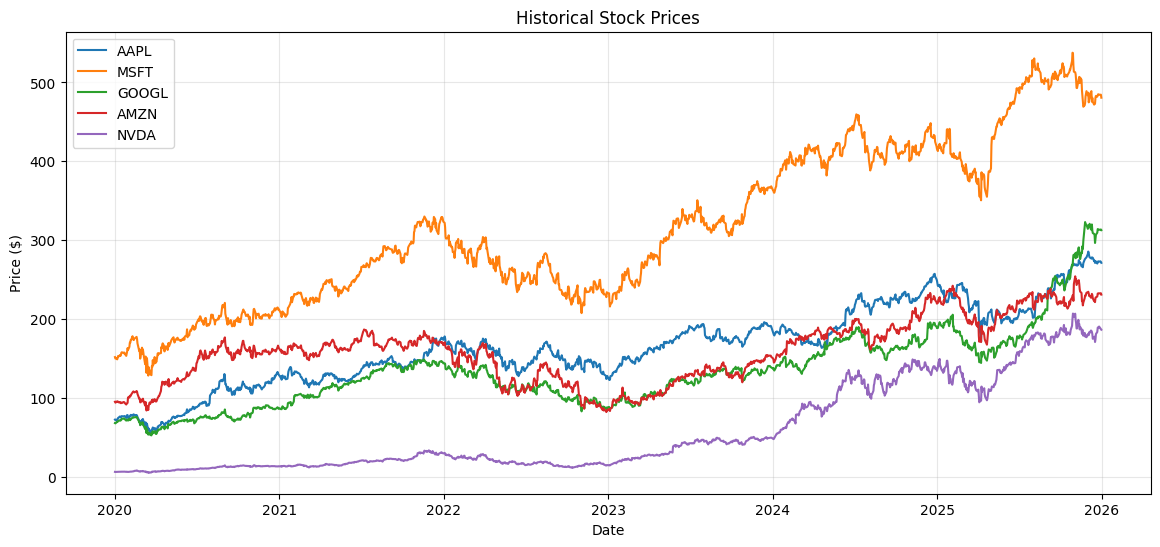

In [6]:
# ============================================
# Step 4: Stock Price Visualization
# ============================================

plt.figure(figsize=(14, 6))

for ticker in tickers:
    plt.plot(prices[ticker], label=ticker)

plt.title("Historical Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

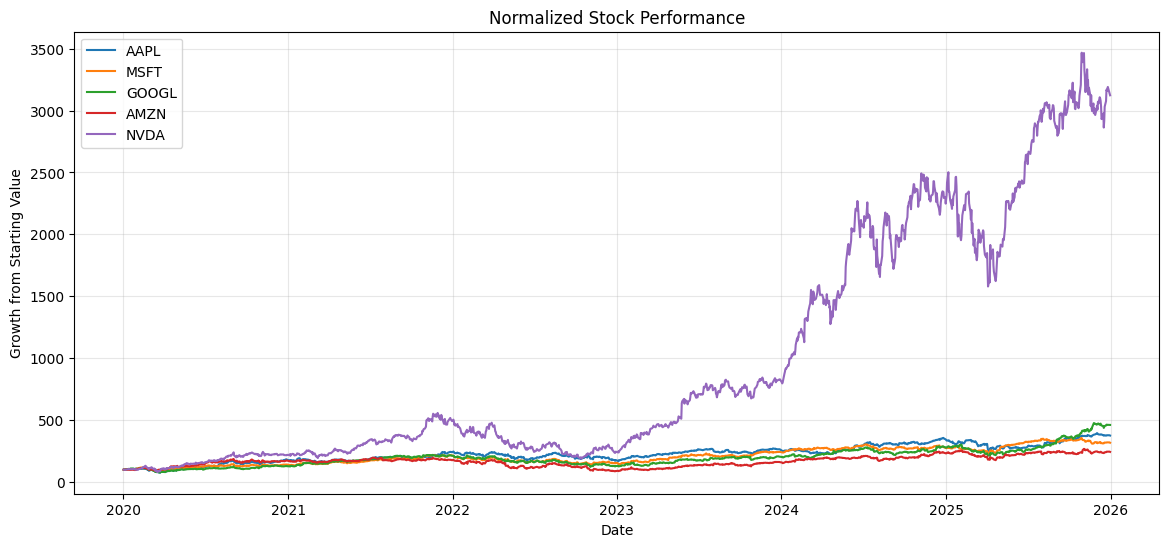

In [7]:
# ============================================
# Step 5: Normalized Prices
# ============================================

normalized_prices = prices / prices.iloc[0] * 100

plt.figure(figsize=(14, 6))

for ticker in tickers:
    plt.plot(normalized_prices[ticker], label=ticker)

plt.title("Normalized Stock Performance")
plt.xlabel("Date")
plt.ylabel("Growth from Starting Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
# ============================================
# Step 6: Calculate Log Returns
# ============================================

returns = np.log(prices / prices.shift(1))

returns = returns.dropna()

returns.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2020-01-03,-0.009769,-0.012213,-0.005245,-0.012530,-0.016136
2020-01-06,0.007936,0.014776,0.026305,0.002581,0.004185
2020-01-07,-0.004714,0.002089,-0.001933,-0.009159,0.012034
2020-01-08,0.015958,-0.007839,0.007092,0.015803,0.001874
2020-01-09,0.021019,0.004788,0.010443,0.012416,0.010923


In [9]:
returns.describe()

Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
count,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000
mean,0.000877,0.000590,0.001014,0.000766,0.002284
std,0.019994,0.022472,0.020454,0.018608,0.033330
min,-0.137708,-0.151398,-0.123685,-0.159454,-0.203979
25%,-0.008243,-0.011169,-0.009467,-0.007941,-0.015703
50%,0.001139,0.000768,0.001704,0.001109,0.003185
75%,0.011399,0.012871,0.011569,0.010372,0.021542
max,0.142617,0.126949,0.097348,0.132929,0.218088


In [10]:
# ============================================
# Step 7: Annualized Return & Volatility
# ============================================

annual_return = returns.mean() * 252

annual_volatility = returns.std() * np.sqrt(252)

statistics = pd.DataFrame({
    "Annual Return": annual_return,
    "Annual Volatility": annual_volatility
})

statistics

,Annual Return,Annual Volatility
Ticker,,
AAPL,0.221088,0.317389
AMZN,0.148626,0.356733
GOOGL,0.255488,0.324693
MSFT,0.192988,0.295387
NVDA,0.575487,0.529105


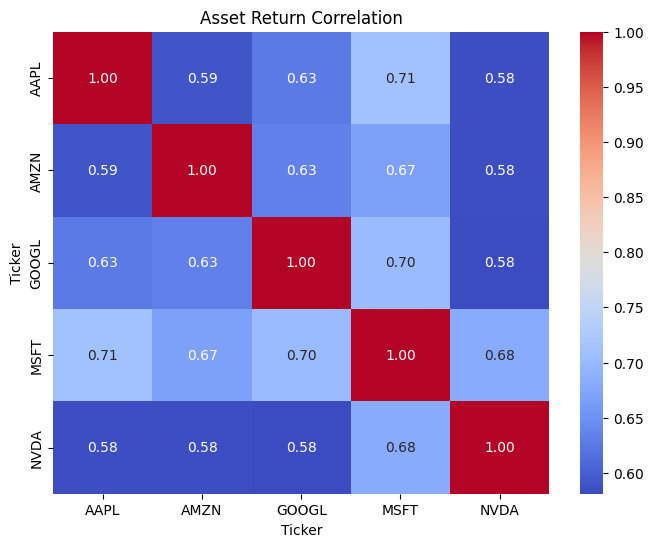

In [11]:
# ============================================
# Step 8: Correlation Matrix
# ============================================

correlation = returns.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Asset Return Correlation")
plt.show()

In [12]:
# ============================================
# Step 9: Annualized Covariance Matrix
# ============================================

covariance = returns.cov() * 252

covariance

Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Ticker,,,,,
AAPL,0.100736,0.066805,0.064464,0.066633,0.097846
AMZN,0.066805,0.127258,0.073251,0.070195,0.110057
GOOGL,0.064464,0.073251,0.105426,0.067288,0.099815
MSFT,0.066633,0.070195,0.067288,0.087254,0.106215
NVDA,0.097846,0.110057,0.099815,0.106215,0.279952


In [13]:
# ============================================
# Step 10: Portfolio Allocation
# ============================================

weights = np.array([
    0.20,  # AAPL
    0.20,  # MSFT
    0.20,  # GOOGL
    0.20,  # AMZN
    0.20   # NVDA
])

print("Total weights:", weights.sum())

Total weights: 1.0


In [14]:
# ============================================
# Step 11: Portfolio Expected Return
# ============================================

portfolio_return = np.dot(weights, annual_return.values)

print(f"Expected Annual Portfolio Return: {portfolio_return:.2%}")

Expected Annual Portfolio Return: 27.87%


In [15]:
# ============================================
# Step 12: Portfolio Volatility
# ============================================

portfolio_volatility = np.sqrt(
    np.dot(weights.T, np.dot(covariance.values, weights))
)

print(f"Annual Portfolio Volatility: {portfolio_volatility:.2%}")

Annual Portfolio Volatility: 30.63%


In [16]:
# ============================================
# Step 13: Monte Carlo Simulation
# ============================================

initial_investment = 100000

days = 252
simulations = 10000

daily_mean = returns.mean().values
daily_covariance = returns.cov().values

# Generate correlated random returns
simulated_returns = np.random.multivariate_normal(
    daily_mean,
    daily_covariance,
    size=(simulations, days)
)

print("Simulation completed!")
print("Number of simulations:", simulations)
print("Days simulated:", days)

Simulation completed!
Number of simulations: 10000
Days simulated: 252


In [17]:
# ============================================
# Step 14: Portfolio Simulated Returns
# ============================================

portfolio_simulated_returns = np.sum(
    simulated_returns * weights,
    axis=2
)

portfolio_simulated_returns.shape

(10000, 252)

In [18]:
# ============================================
# Step 15: Simulated Portfolio Paths
# ============================================

portfolio_paths = initial_investment * np.exp(
    np.cumsum(portfolio_simulated_returns, axis=1)
)

print("Portfolio simulation matrix shape:")
print(portfolio_paths.shape)

Portfolio simulation matrix shape:
(10000, 252)


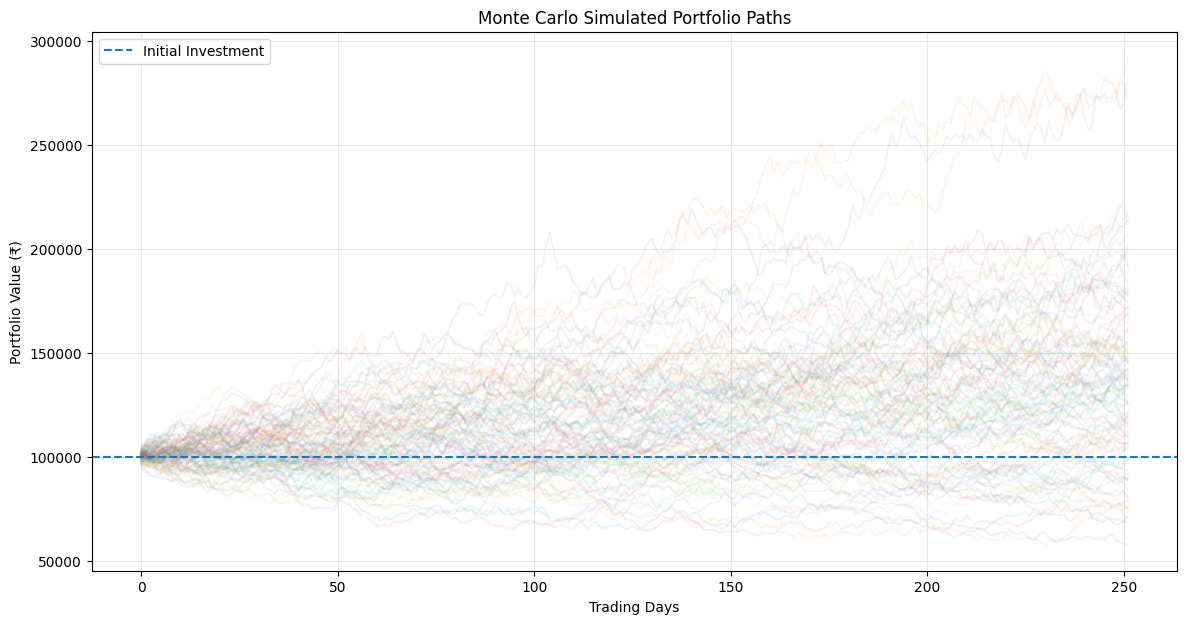

In [19]:
# ============================================
# Step 16: Monte Carlo Paths
# ============================================

plt.figure(figsize=(14, 7))

# Plot first 100 simulations
plt.plot(
    portfolio_paths[:100].T,
    alpha=0.08
)

plt.title("Monte Carlo Simulated Portfolio Paths")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value (₹)")

plt.axhline(
    initial_investment,
    linestyle="--",
    label="Initial Investment"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [20]:
# ============================================
# Step 17: Final Portfolio Values
# ============================================

final_values = portfolio_paths[:, -1]

print("Mean final value:",
      f"₹{final_values.mean():,.2f}")

print("Median final value:",
      f"₹{np.median(final_values):,.2f}")

print("Minimum:",
      f"₹{final_values.min():,.2f}")

print("Maximum:",
      f"₹{final_values.max():,.2f}")

Mean final value: ₹138,949.61
Median final value: ₹132,829.18
Minimum: ₹42,709.16
Maximum: ₹447,459.13


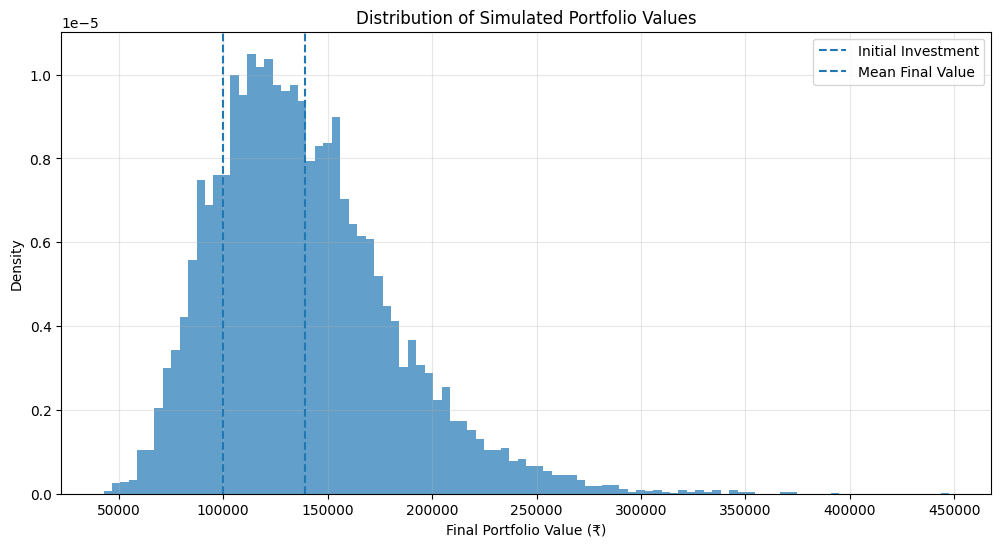

In [21]:
# ============================================
# Step 18: Final Value Distribution
# ============================================

plt.figure(figsize=(12, 6))

plt.hist(
    final_values,
    bins=100,
    density=True,
    alpha=0.7
)

plt.axvline(
    initial_investment,
    linestyle="--",
    label="Initial Investment"
)

plt.axvline(
    np.mean(final_values),
    linestyle="--",
    label="Mean Final Value"
)

plt.title("Distribution of Simulated Portfolio Values")
plt.xlabel("Final Portfolio Value (₹)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [22]:
# ============================================
# Step 19: Probability of Loss
# ============================================

probability_loss = np.mean(
    final_values < initial_investment
)

print(
    f"Probability of Loss: {probability_loss:.2%}"
)

Probability of Loss: 18.09%


In [23]:
# ============================================
# Step 20: Simulated Profit/Loss
# ============================================

profits_losses = final_values - initial_investment

print("Expected Profit/Loss:",
      f"₹{profits_losses.mean():,.2f}")

print("Worst simulated loss:",
      f"₹{profits_losses.min():,.2f}")

print("Best simulated profit:",
      f"₹{profits_losses.max():,.2f}")

Expected Profit/Loss: ₹38,949.61
Worst simulated loss: ₹-57,290.84
Best simulated profit: ₹347,459.13


In [24]:
# ============================================
# Step 21: Value at Risk
# ============================================

confidence_level = 0.95

var_percentile = np.percentile(
    profits_losses,
    (1 - confidence_level) * 100
)

VaR_95 = -var_percentile

print(f"95% VaR: ₹{VaR_95:,.2f}")

95% VaR: ₹20,153.43


In [25]:
# ============================================
# Step 22: Conditional VaR / Expected Shortfall
# ============================================

var_threshold = np.percentile(
    profits_losses,
    5
)

tail_losses = profits_losses[
    profits_losses <= var_threshold
]

CVaR_95 = -tail_losses.mean()

print(f"95% CVaR: ₹{CVaR_95:,.2f}")

95% CVaR: ₹29,188.62


In [26]:
# ============================================
# Step 23: Confidence Interval
# ============================================

lower = np.percentile(final_values, 5)
upper = np.percentile(final_values, 95)

print(
    f"90% simulated range: ₹{lower:,.2f} - ₹{upper:,.2f}"
)

90% simulated range: ₹79,846.57 - ₹218,551.69


In [27]:
# ============================================
# Step 24: Maximum Drawdown
# ============================================

running_max = np.maximum.accumulate(
    portfolio_paths,
    axis=1
)

drawdowns = (
    portfolio_paths - running_max
) / running_max

max_drawdowns = drawdowns.min(axis=1)

average_max_drawdown = max_drawdowns.mean()

worst_max_drawdown = max_drawdowns.min()

print(
    f"Average Maximum Drawdown: "
    f"{average_max_drawdown:.2%}"
)

print(
    f"Worst Simulated Drawdown: "
    f"{worst_max_drawdown:.2%}"
)

Average Maximum Drawdown: -22.96%
Worst Simulated Drawdown: -61.27%


In [28]:
# ============================================
# Step 25: Risk Summary
# ============================================

summary = pd.DataFrame({
    "Metric": [
        "Initial Investment",
        "Expected Annual Return",
        "Annual Volatility",
        "Expected Final Value",
        "Probability of Loss",
        "95% VaR",
        "95% CVaR",
        "Average Maximum Drawdown",
        "Worst Maximum Drawdown"
    ],

    "Value": [
        f"₹{initial_investment:,.2f}",
        f"{portfolio_return:.2%}",
        f"{portfolio_volatility:.2%}",
        f"₹{final_values.mean():,.2f}",
        f"{probability_loss:.2%}",
        f"₹{VaR_95:,.2f}",
        f"₹{CVaR_95:,.2f}",
        f"{average_max_drawdown:.2%}",
        f"{worst_max_drawdown:.2%}"
    ]
})

summary

,Metric,Value
0,Initial Investment,"₹100,000.00"
1,Expected Annual Return,27.87%
2,Annual Volatility,30.63%
3,Expected Final Value,"₹138,949.61"
4,Probability of Loss,18.09%
5,95% VaR,"₹20,153.43"
6,95% CVaR,"₹29,188.62"
7,Average Maximum Drawdown,-22.96%
8,Worst Maximum Drawdown,-61.27%


In [29]:
# ============================================
# Step 26: Portfolio Configurations
# ============================================

portfolios = {

    "Conservative": np.array([
        0.10, 0.30, 0.30, 0.10, 0.20
    ]),

    "Balanced": np.array([
        0.20, 0.20, 0.20, 0.20, 0.20
    ]),

    "Aggressive": np.array([
        0.10, 0.10, 0.10, 0.20, 0.50
    ])
}

In [30]:
# ============================================
# Portfolio Risk/Return Comparison
# ============================================

portfolio_comparison = []

for name, w in portfolios.items():

    expected_return = np.dot(
        w,
        annual_return.values
    )

    volatility = np.sqrt(
        np.dot(
            w.T,
            np.dot(covariance.values, w)
        )
    )

    portfolio_comparison.append({
        "Portfolio": name,
        "Expected Return": expected_return,
        "Volatility": volatility
    })

comparison_df = pd.DataFrame(
    portfolio_comparison
)

comparison_df

,Portfolio,Expected Return,Volatility
0,Conservative,0.277739,0.313065
1,Balanced,0.278735,0.306318
2,Aggressive,0.388861,0.375609


In [31]:
# ============================================
# Step 27: Monte Carlo Convergence
# ============================================

simulation_counts = [
    100,
    500,
    1000,
    5000,
    10000
]

estimated_values = []

for n in simulation_counts:

    simulated = np.random.multivariate_normal(
        daily_mean,
        daily_covariance,
        size=(n, days)
    )

    portfolio_returns = np.sum(
        simulated * weights,
        axis=2
    )

    paths = initial_investment * np.exp(
        np.cumsum(portfolio_returns, axis=1)
    )

    final = paths[:, -1]

    estimated_values.append(
        final.mean()
    )

convergence_df = pd.DataFrame({
    "Simulations": simulation_counts,
    "Estimated Final Value": estimated_values
})

convergence_df

,Simulations,Estimated Final Value
0,100,130746.207221
1,500,136535.979186
2,1000,137813.899169
3,5000,138267.653528
4,10000,138566.139561


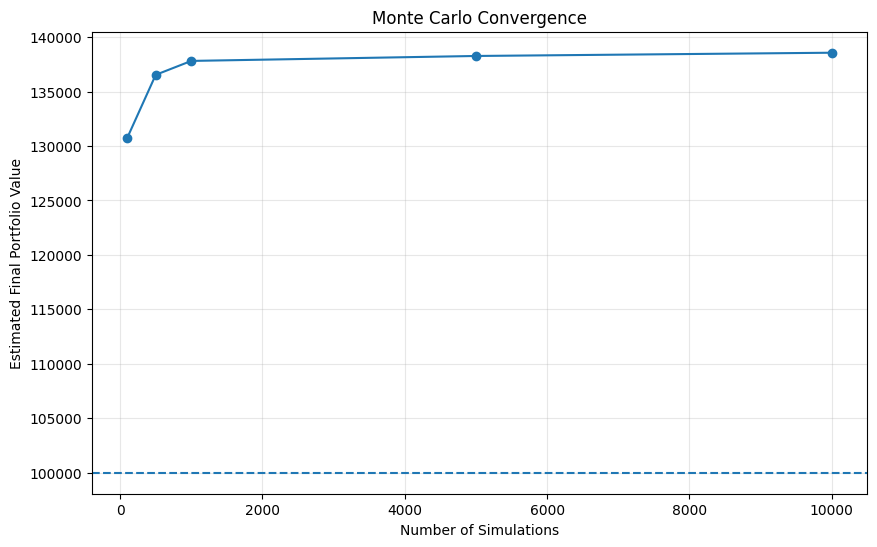

In [32]:
plt.figure(figsize=(10, 6))

plt.plot(
    convergence_df["Simulations"],
    convergence_df["Estimated Final Value"],
    marker="o"
)

plt.axhline(
    initial_investment,
    linestyle="--"
)

plt.title("Monte Carlo Convergence")
plt.xlabel("Number of Simulations")
plt.ylabel("Estimated Final Portfolio Value")

plt.grid(alpha=0.3)
plt.show()

In [33]:
# ============================================
# Step 28: Stress Test
# ============================================

stress_covariance = daily_covariance * (1.5 ** 2)

stress_simulated = np.random.multivariate_normal(
    daily_mean,
    stress_covariance,
    size=(10000, days)
)

stress_portfolio_returns = np.sum(
    stress_simulated * weights,
    axis=2
)

stress_paths = initial_investment * np.exp(
    np.cumsum(
        stress_portfolio_returns,
        axis=1
    )
)

stress_final = stress_paths[:, -1]

stress_loss_probability = np.mean(
    stress_final < initial_investment
)

print(
    f"Stress Scenario Loss Probability: "
    f"{stress_loss_probability:.2%}"
)

Stress Scenario Loss Probability: 28.07%


In [34]:
print("NORMAL SCENARIO")
print("----------------")
print(
    f"Expected Final Value: "
    f"₹{final_values.mean():,.2f}"
)

print(
    f"Probability of Loss: "
    f"{probability_loss:.2%}"
)

print("\nSTRESS SCENARIO")
print("----------------")
print(
    f"Expected Final Value: "
    f"₹{stress_final.mean():,.2f}"
)

print(
    f"Probability of Loss: "
    f"{stress_loss_probability:.2%}"
)

NORMAL SCENARIO
----------------
Expected Final Value: ₹138,949.61
Probability of Loss: 18.09%

STRESS SCENARIO
----------------
Expected Final Value: ₹146,038.38
Probability of Loss: 28.07%


In [35]:
# ============================================
# FINAL PROJECT METRICS
# ============================================

print("=" * 55)
print("      MONTE CARLO PORTFOLIO RISK REPORT")
print("=" * 55)

print(f"Initial Investment       : ₹{initial_investment:,.2f}")
print(f"Simulations              : {simulations:,}")
print(f"Investment Horizon       : {days} trading days")
print(f"Expected Annual Return   : {portfolio_return:.2%}")
print(f"Annual Volatility        : {portfolio_volatility:.2%}")
print(f"Expected Final Value     : ₹{final_values.mean():,.2f}")
print(f"Probability of Loss      : {probability_loss:.2%}")
print(f"95% VaR                  : ₹{VaR_95:,.2f}")
print(f"95% CVaR                 : ₹{CVaR_95:,.2f}")
print(f"Average Max Drawdown     : {average_max_drawdown:.2%}")
print(f"Worst Max Drawdown       : {worst_max_drawdown:.2%}")

print("=" * 55)

      MONTE CARLO PORTFOLIO RISK REPORT
Initial Investment       : ₹100,000.00
Simulations              : 10,000
Investment Horizon       : 252 trading days
Expected Annual Return   : 27.87%
Annual Volatility        : 30.63%
Expected Final Value     : ₹138,949.61
Probability of Loss      : 18.09%
95% VaR                  : ₹20,153.43
95% CVaR                 : ₹29,188.62
Average Max Drawdown     : -22.96%
Worst Max Drawdown       : -61.27%
